In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv('/content/monthly_milk_production.csv')

In [3]:
df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [4]:
df.shape

(168, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB


In [6]:
df.describe()

,Production
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000


--- Missing Values ---
Date          0
Production    0
dtype: int64


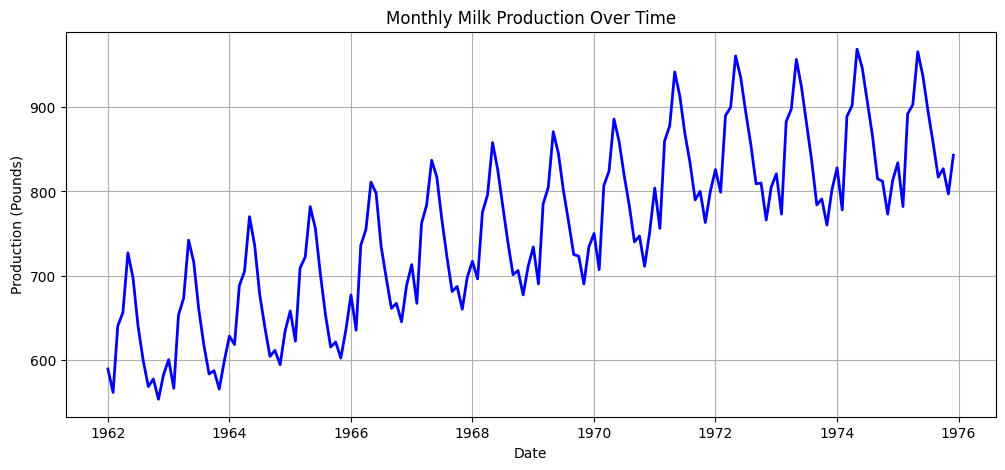

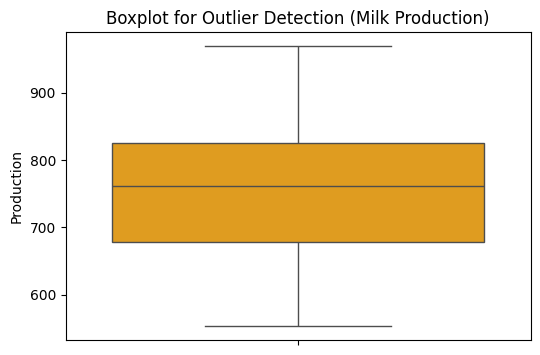


First 5 rows of scaled data:
            Production  Scaled_Production
Date                                     
1962-01-01         589           0.086538
1962-02-01         561           0.019231
1962-03-01         640           0.209135
1962-04-01         656           0.247596
1962-05-01         727           0.418269


In [8]:
# Check for Missing Values & Data Types
print('--- Missing Values ---')
print(df.isnull().sum())

# now lets Convert 'Date' column to datetime type
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

# next step is to Visualize Time Series Trends and Seasonality
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Production'], color='b', linewidth=2)
plt.title('Monthly Milk Production Over Time')
plt.xlabel('Date')
plt.ylabel('Production (Pounds)')
plt.grid(True)
plt.show()

# Outlier Check using a Boxplot
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['Production'], color='orange')
plt.title('Boxplot for Outlier Detection (Milk Production)')
plt.show()

# Normalize/Scale the Data (Neural networks require values scaled between 0 and 1)
scaler = MinMaxScaler(feature_range=(0, 1))
df['Scaled_Production'] = scaler.fit_transform(df[['Production']])

print('\nFirst 5 rows of scaled data:')
print(df.head())

In [9]:
#  DATA PREPARATION FOR DEEP LEARNING
# Function to create time-window sequences (
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size)])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

# Define lookback window size
window_size = 12

scaled_data = df['Scaled_Production'].values
X, y = create_sequences(scaled_data, window_size)

# Split into Training, Validation, and Test Sets , Time-series splits must remain sequential (no random shuffling)
train_size = int(len(X) * 0.70)
val_size = int(len(X) * 0.15)

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size + val_size], y[train_size:train_size + val_size]
X_test, y_test = X[train_size + val_size:], y[train_size + val_size:]

#  Reshape data for RNN/LSTM/GRU input dimensions
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape},   y_val shape:   {y_val.shape}")
print(f"X_test shape:  {X_test.shape},  y_test shape:  {y_test.shape}")

X_train shape: (109, 12, 1), y_train shape: (109,)
X_val shape:   (23, 12, 1),   y_val shape:   (23,)
X_test shape:  (24, 12, 1),  y_test shape:  (24,)


In [10]:
#MODEL BUILDING & TRAINING (RNN, LSTM, GRU)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# Set random seed for reproducibility
tf.keras.utils.set_random_seed(42)

# Define hyperparameters
n_units = 50
batch_size = 16
epochs = 50

# MODEL 1: Basic RNN
print("--- Training Basic RNN Model ---")
rnn_model = Sequential([
    SimpleRNN(units=n_units, activation='relu', input_shape=(X_train.shape[1], 1)),
    Dense(units=1)
])
rnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

rnn_history = rnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=batch_size,
    epochs=epochs,
    verbose=0
)
print("Basic RNN Training Complete.")


# MODEL 2: LSTM
print("--- Training LSTM Model ---")
lstm_model = Sequential([
    LSTM(units=n_units, activation='relu', input_shape=(X_train.shape[1], 1)),
    Dense(units=1)
])
lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=batch_size,
    epochs=epochs,
    verbose=0
)
print("LSTM Training Complete.")


# MODEL 3: GRU
print("--- Training GRU Model ---")
gru_model = Sequential([
    GRU(units=n_units, activation='relu', input_shape=(X_train.shape[1], 1)),
    Dense(units=1)
])
gru_model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

gru_history = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=batch_size,
    epochs=epochs,
    verbose=0
)
print("GRU Training Complete.")

--- Training Basic RNN Model ---


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Basic RNN Training Complete.
--- Training LSTM Model ---
LSTM Training Complete.
--- Training GRU Model ---
GRU Training Complete.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
--- Model Performance Comparison ---
    Model      RMSE       MAE  MAPE (%)
Basic RNN 12.015827  9.694364  1.133018
     LSTM 46.075576 34.289571  4.009614
      GRU 37.693232 27.732206  3.264381


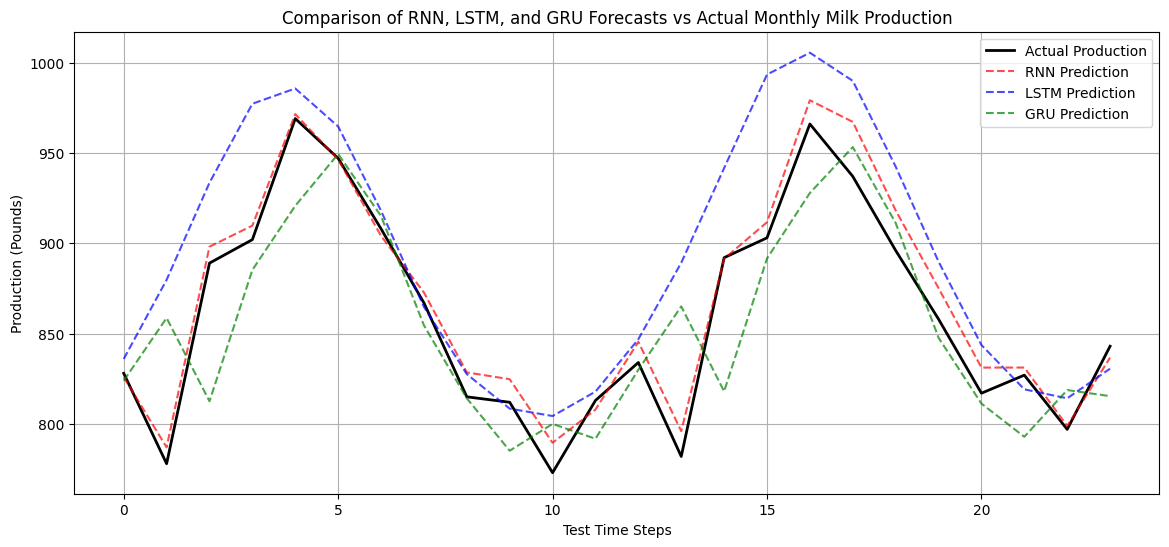

In [11]:
#MODEL EVALUATION & COMPARISON

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Generate Predictions for all three models
rnn_preds = rnn_model.predict(X_test)
lstm_preds = lstm_model.predict(X_test)
gru_preds = gru_model.predict(X_test)

y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
rnn_preds_inv = scaler.inverse_transform(rnn_preds)
lstm_preds_inv = scaler.inverse_transform(lstm_preds)
gru_preds_inv = scaler.inverse_transform(gru_preds)


# Function to calculate evaluation metrics (RMSE, MAE, MAPE)
def evaluate_forecast(actual, predicted):
  rmse = np.sqrt(mean_squared_error(actual, predicted))
  mae = mean_absolute_error(actual, predicted)
  mape = np.mean(np.abs((actual - predicted) / actual)) * 100
  return rmse, mae, mape


rnn_metrics = evaluate_forecast(y_test_actual, rnn_preds_inv)
lstm_metrics = evaluate_forecast(y_test_actual, lstm_preds_inv)
gru_metrics = evaluate_forecast(y_test_actual, gru_preds_inv)

#  Display Metrics Comparison in a DataFrame
metrics_df = pd.DataFrame(
    {
        'Model': ['Basic RNN', 'LSTM', 'GRU'],
        'RMSE': [rnn_metrics[0], lstm_metrics[0], gru_metrics[0]],
        'MAE': [rnn_metrics[1], lstm_metrics[1], gru_metrics[1]],
        'MAPE (%)': [rnn_metrics[2], lstm_metrics[2], gru_metrics[2]],
    }
)

print('--- Model Performance Comparison ---')
print(metrics_df.to_string(index=False))

#  Plotting
plt.figure(figsize=(14, 6))
plt.plot(y_test_actual, label='Actual Production', color='black', linewidth=2)
plt.plot(
    rnn_preds_inv,
    label='RNN Prediction',
    color='red',
    linestyle='--',
    alpha=0.7,
)
plt.plot(
    lstm_preds_inv,
    label='LSTM Prediction',
    color='blue',
    linestyle='--',
    alpha=0.7,
)
plt.plot(
    gru_preds_inv,
    label='GRU Prediction',
    color='green',
    linestyle='--',
    alpha=0.7,
)

plt.title('Comparison of RNN, LSTM, and GRU Forecasts vs Actual Monthly Milk Production')
plt.xlabel('Test Time Steps')
plt.ylabel('Production (Pounds)')
plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


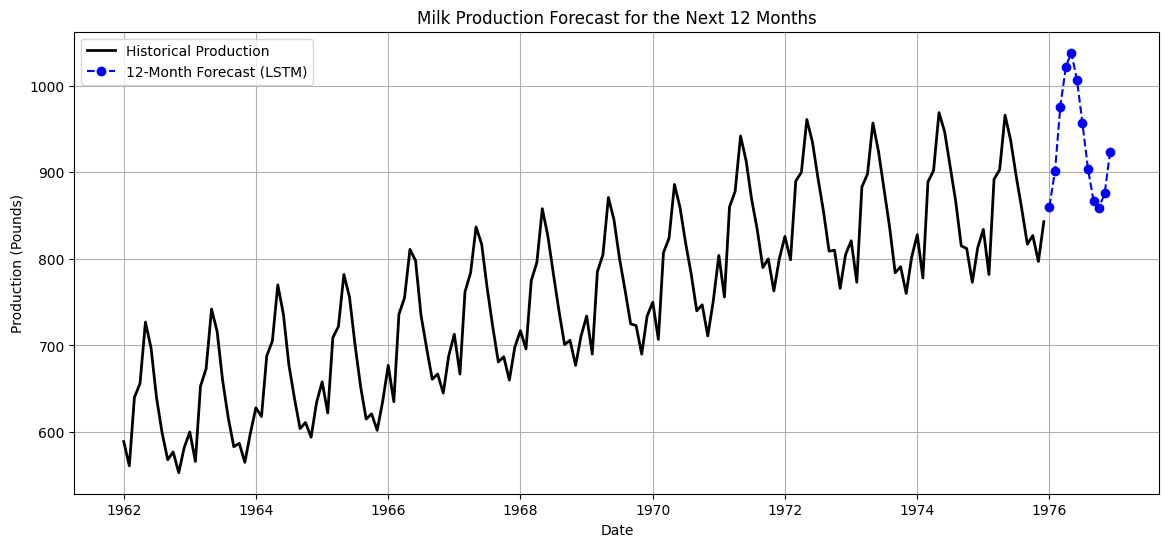

--- 12-Month Future Forecast ---
      Date  Predicted_Production
1976-01-01            860.535889
1976-02-01            902.031494
1976-03-01            975.754272
1976-04-01           1022.244629
1976-05-01           1038.178589
1976-06-01           1006.835571
1976-07-01            957.162598
1976-08-01            904.036560
1976-09-01            866.813049
1976-10-01            859.166382
1976-11-01            875.742798
1976-12-01            923.434692


In [12]:
# 1. Use the best modelto forecast future months
current_batch = scaled_data[-window_size:].reshape(1, window_size, 1)
future_predictions = []

# Forecast step-by-step for the next 12 months
for i in range(12):
  # Get prediction for the next month
  current_pred = lstm_model.predict(current_batch)[0][0]
  # Append prediction to list
  future_predictions.append(current_pred)
  # Update the batch to drop the oldest value and add the new prediction
  current_batch = np.append(
      current_batch[:, 1:, :], [[[current_pred]]], axis=1
  )

future_predictions_inv = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1, 1)
)

#  Create a future date range for plotting
last_date = df.index[-1]
future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1), periods=12, freq='MS'
)

# Plot Historical Data alongside the 12-Month Forecast
plt.figure(figsize=(14, 6))
plt.plot(
    df.index,
    df['Production'],
    label='Historical Production',
    color='black',
    linewidth=2,
)
plt.plot(
    future_dates,
    future_predictions_inv,
    label='12-Month Forecast (LSTM)',
    color='blue',
    linestyle='--',
    marker='o',
)

plt.title('Milk Production Forecast for the Next 12 Months')
plt.xlabel('Date')
plt.ylabel('Production (Pounds)')
plt.legend()
plt.grid(True)
plt.show()

# Display the numerical values of the forecast
forecast_df = pd.DataFrame(
    {'Date': future_dates, 'Predicted_Production': future_predictions_inv.flatten()}
)
print('--- 12-Month Future Forecast ---')
print(forecast_df.to_string(index=False))

In [6]:
#Based on our exploratory data analysis and the performance of our deep learning models (RNN, LSTM, and GRU), the monthly milk production data exhibits strong, recurring annual seasonality alongside an overall structural trend. By leveraging the 12-month future predictions generated by our LSTM model, the dairy business can transition from reactive planning to proactive optimization across the following operational pillars:
 #Supply Chain and Distribution Planning- Recommendation: Align transportation logistics, milk collection tankers, and cold-chain distribution networks dynamically with the predicted volume changes. Scale up transport fleets ahead of peak production months to prevent bottlenecks and eliminate product spoilage risks.
 #Inventory and Storage Management - optimize cold storage capacity and processing plant inventories (e.g., butter, cheese, and powdered milk conversion facilities). During peak production months, divert excess raw milk into stable, long-shelf-life dairy products to prevent market over-saturation and price drops.
  #Workforce and Operational Resource Allocation - Use forecasted troughs to schedule routine facility maintenance, equipment upgrades, and staff leave. Conversely, ramp up temporary staffing and processing line shifts ahead of anticipated high-yield months to maintain optimal operational efficiency.
#Strategic Financial & Scaling Decisions - Use the forecasted revenue streams to negotiate better long-term supply contracts with commercial buyers, manage feed purchasing budgets proactively, and make data-driven capital expenditure decisions regarding farm expansion or livestock scaling.